In [3]:
import pandas as pd

df = pd.read_csv("dataset_jeruk_struktur_baru_500.csv")
df

,ukuran_cm,berat_gram,tingkat_kemanisan,tingkat_keasaman,warna_kulit,tekstur_kulit,musim,kualitas
0,9.18,260.7,11.83,3.93,Hijau,Sedikit Kasar,Hujan,Sedang
1,7.67,158.7,9.14,3.46,Kuning,Kasar,Hujan,Jelek
2,8.02,229.3,12.20,2.91,Kuning,Halus,Hujan,Bagus
3,8.29,205.6,10.63,3.85,Oranye,Kasar,Hujan,Sedang
4,7.45,189.3,11.63,4.31,Hijau,Halus,Kemarau,Sedang
...,...,...,...,...,...,...,...,...
495,8.51,216.2,9.03,4.64,Kuning,Kasar,Kemarau,Jelek
496,8.80,231.7,11.54,4.99,Oranye,Halus,Kemarau,Sedang
497,7.89,200.3,11.41,4.01,Hijau,Halus,Kemarau,Sedang
498,7.10,196.1,13.61,3.65,Kuning,Sedikit Kasar,Hujan,Bagus


In [4]:
df.describe()

,ukuran_cm,berat_gram,tingkat_kemanisan,tingkat_keasaman
count,500.00000,500.000000,500.000000,500.000000
mean,7.95452,215.238600,10.513040,3.741080
std,0.68466,28.425598,1.532224,0.603072
min,5.84000,125.000000,5.620000,2.010000
25%,7.53000,195.350000,9.450000,3.350000
50%,7.95000,215.200000,10.565000,3.735000
75%,8.42000,235.200000,11.602500,4.112500
max,10.00000,292.800000,15.010000,6.050000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ukuran_cm          500 non-null    float64
 1   berat_gram         500 non-null    float64
 2   tingkat_kemanisan  500 non-null    float64
 3   tingkat_keasaman   500 non-null    float64
 4   warna_kulit        500 non-null    object 
 5   tekstur_kulit      500 non-null    object 
 6   musim              500 non-null    object 
 7   kualitas           500 non-null    object 
dtypes: float64(4), object(4)
memory usage: 31.4+ KB


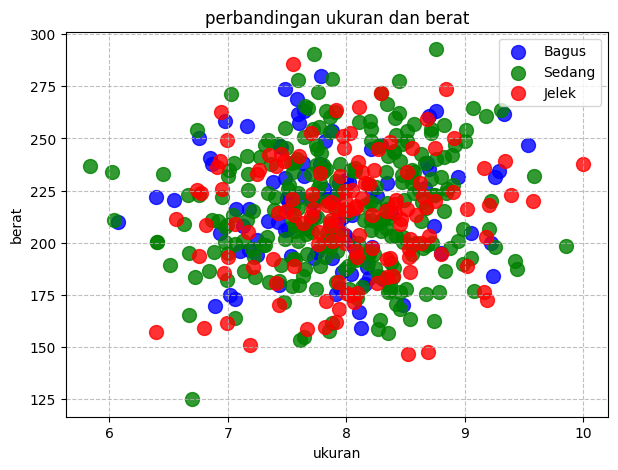

In [30]:
import matplotlib.pyplot as plt

bagus = df[df["kualitas"]=="Bagus"]
sedang = df[df["kualitas"]=="Sedang"]
jelek = df[df["kualitas"]=="Jelek"]

plt.figure(figsize=(7,5))

plt.scatter(bagus["ukuran_cm"], bagus["berat_gram"], s=100, alpha=0.8, color="blue", label="Bagus")
plt.scatter(sedang["ukuran_cm"], sedang["berat_gram"], s=100, alpha=0.8, color="green", label="Sedang")
plt.scatter(jelek["ukuran_cm"], jelek["berat_gram"], s=100, alpha=0.8, color="red", label="Jelek")
plt.xlabel("ukuran")
plt.ylabel("berat")
plt.title("perbandingan ukuran dan berat")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.8)
plt.show()

In [67]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

X = df[["ukuran_cm","berat_gram","tingkat_kemanisan","tingkat_keasaman","warna_kulit","tekstur_kulit","musim"]]
y = df["kualitas"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

numeric_columns = ["ukuran_cm","berat_gram","tingkat_kemanisan","tingkat_keasaman"]
ordinal_columns = ["tekstur_kulit","musim"]
categorical_columns = ["warna_kulit"]

tekstur_order = ["Halus","Sedikit Kasar","Kasar"]
musim_order = ["Kemarau","Hujan"]

ordinal_order = [tekstur_order, musim_order]

preprocessing = ColumnTransformer(
    transformers=[
        ("scaler", StandardScaler(), numeric_columns),
        ("ohe", OneHotEncoder(handle_unknown="ignore"), categorical_columns),
        ("oe", OrdinalEncoder(categories=ordinal_order), ordinal_columns)
    ]
)

model = Pipeline(
    steps=[
        ("preprocessing", preprocessing),
        ("model", LogisticRegression())
    ]
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy :", accuracy_score(y_test, y_pred))
print("\nClassification Report :\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix :\n", confusion_matrix(y_test, y_pred))

Accuracy : 0.89

Classification Report :
               precision    recall  f1-score   support

       Bagus       0.84      0.76      0.80        21
       Jelek       1.00      0.91      0.95        32
      Sedang       0.85      0.94      0.89        47

    accuracy                           0.89       100
   macro avg       0.90      0.87      0.88       100
weighted avg       0.89      0.89      0.89       100


Confusion Matrix :
 [[16  0  5]
 [ 0 29  3]
 [ 3  0 44]]


In [79]:
data_baru = pd.DataFrame([[8, 220, 9.5, 12, "Hijau", "Kasar", "Hujan"]],
                         columns=["ukuran_cm","berat_gram","tingkat_kemanisan","tingkat_keasaman","warna_kulit","tekstur_kulit","musim"])
prediksi = model.predict(data_baru)[0]
presentase = max(model.predict_proba(data_baru)[0])
print(f"model memprediksi {prediksi} dengan tingkat keyakinan {presentase*100:.2f}%")

model memprediksi Sedang dengan tingkat keyakinan 97.87%


In [80]:
import joblib

joblib.dump(model, "ujicoba.joblib")

['ujicoba.joblib']